# Heart Attack Prediction Analysis

This notebook analyzes a heart attack dataset, visualizes feature correlations, and evaluates multiple machine learning models to predict heart attack risk.

## Import Libraries

First, we'll import the necessary libraries for data analysis and visualization.

In [18]:
# ---------------------
# CODE HERE
# ---------------------
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Load the Dataset

Load the heart attack dataset from the CSV file and display basic information about it.

In [19]:
# Import the dataset by using pandas
# ---------------------
# CODE HERE
# ---------------------
df = pd.read_csv('Heart_Attack.csv')

# Display the first 5 rows of the dataset
# ---------------------
# CODE HERE
# ---------------------
df.head(5)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [20]:
# Display the statistical information of the dataset
# ---------------------
# CODE HERE
# ---------------------
df.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Data Cleaning
Check for missing values and handle them if necessary.

In [21]:
# Data Cleaning
# ---------------------
# CODE HERE
# ---------------------
df = df.dropna()

## Correlation Analysis

Calculate and display the correlation matrix to understand relationships between variables.

In [22]:
# Calculate the correlation of the dataset
# Save the result in a variable called corr
corr = df.corr()

## Visualize Correlation Matrix

Create a heatmap to visualize the correlation between features.

C:\Users\Acer\AppData\Local\Temp\ipykernel_20668\1167481190.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(df.columns)
C:\Users\Acer\AppData\Local\Temp\ipykernel_20668\1167481190.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  text = ax.text(j, i, round(corr.iloc[i][j],2),


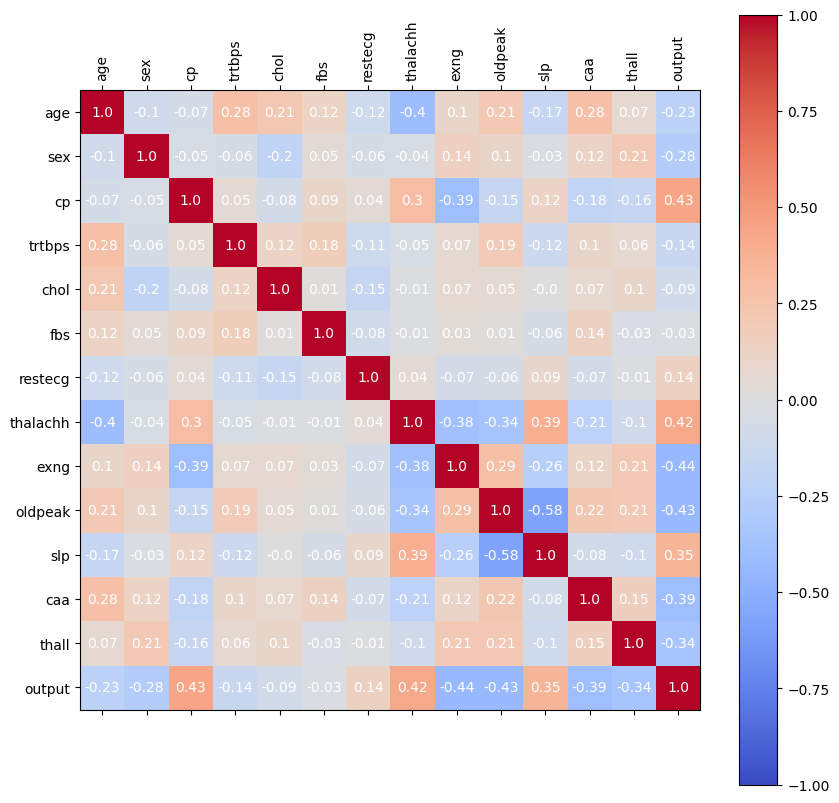

In [23]:
# Plot the correlation matrix (corr) using seaborn
fig, ax = plt.subplots(figsize=(10, 10))
cax = ax.matshow(corr,cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)
ticks = np.arange(0,len(df.columns),1)
ax.set_xticks(ticks)
ax.set_xticklabels(df.columns)
plt.xticks(rotation = 90)
ax.set_yticklabels(df.columns)
ax.set_yticks(ticks)
#---print the correlation factor---
for i in range(df.shape[1]):
    for j in range(df.shape[1]):
        text = ax.text(j, i, round(corr.iloc[i][j],2),
        ha="center", va="center", color="w")
plt.show()

## Feature Selection and Target Variable

Select the most relevant features for our model and define the target variable.
<br>Note. For this task we will choose 4 features.

In [24]:
# Split the dataset into X and y
# X contains the selected columns
# y contains the target column
# ---------------------
# CODE HERE
# ---------------------
X = df[['cp', 'thalachh', 'slp', 'restecg']]
y = df['output']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Data Preprocessing: Feature Scaling (Optional)

Standardize the features to have mean=0 and variance=1, which is important for many ML algorithms.
<br>Note. If you use this Data Preprocessing step, you should also apply it to the prediction step as well.

In [25]:
# Data Preprocessing (optional)
# ---------------------
# CODE HERE
# ---------------------
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

## Model Evaluation Using Cross-Validation

We'll evaluate multiple machine learning models using 10-fold cross-validation to find the best performer.
<br>Note. The train/test split is not necessary when using cross-validation because the data is split into training and testing sets multiple times.

In [26]:
# Import the cross_val_score from sklearn
from sklearn.model_selection import cross_val_score

### Logistic Regression

In [27]:
from sklearn.linear_model import LogisticRegression

logRe = LogisticRegression()
logRe_score = cross_val_score(logRe, X_train, y_train, cv=5, scoring='accuracy').mean()
print('LogisticRegression',logRe_score)

LogisticRegression 0.7318877551020408


### K-Nearest Neighbors

Test different values of k to find the optimal number of neighbors.

In [28]:
from polars import fold
from sklearn.neighbors import KNeighborsClassifier

folds = 10
cv_scores = []
min_class_count = pd.Series(y_train).value_counts().min()
safe_max_k = int(min_class_count * ((folds - 1) / folds))

if safe_max_k < 1:
    ks = [1]
else:
    ks = list(range(1, safe_max_k + 1, 2))
    if not ks: 
        ks = [1]

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_train, y_train, cv=folds, scoring='accuracy').mean()
    cv_scores.append(score)

if cv_scores:
    knn_score = max(cv_scores)
    optimal_k = ks[cv_scores.index(knn_score)]
    print('kNN: (Optimal k = {}, Score = {})'.format(optimal_k, knn_score))

kNN: (Optimal k = 83, Score = 0.6984999999999999)


### Decision Tree

Test different tree depths to find the optimal complexity.

In [29]:
from sklearn.tree import DecisionTreeClassifier

depth = []
for i in range(3,20):
    clf = DecisionTreeClassifier(max_depth=i)
    scores = cross_val_score(clf, X_train, y_train, cv=5, n_jobs=4)
    depth.append([i,scores.mean()])
depth = np.array(depth)
d = depth[np.argmax(depth[:,1], axis=0),0]
s = depth[np.argmax(depth[:,1], axis=0),1]
print('Tree',(d,s))

Tree (np.float64(5.0), np.float64(0.731547619047619))


### Support Vector Machines

Test SVM with different kernels: linear and radial basis function (RBF).

In [30]:
from sklearn import svm

# Linear kernel
linear_svm = svm.SVC(kernel='linear')
linear_svm_score = cross_val_score(linear_svm, X_train, y_train, cv=5, scoring='accuracy').mean()
print('SVM-L',linear_svm_score)

# RBF kernel
rbf_svm = svm.SVC(kernel='rbf')
rbf_svm_score = cross_val_score(rbf_svm, X_train, y_train, cv=5, scoring='accuracy').mean()
print('SVM-rbf',rbf_svm_score)

SVM-L 0.7440476190476191
SVM-rbf 0.6693027210884354


### Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf_score = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy').mean()
print('Random Forest',rf_score)

Random Forest 0.6534013605442177


# Conclusion

In [32]:
print('Best model is', 'Logistic Regression')

Best model is Logistic Regression


## Train and Save the Best Model

Based on the evaluation, we'll train the Logistic Regression model on the full dataset and save it for future use.

In [33]:
import pickle

# Train the final model using the best algorithm
# In this case, we will use the whole dataset to train the model
# ---------------------
# CODE HERE
# ---------------------

lr = logRe.fit(X, y)



Save the model to a file using the pickle library.

In [34]:
# Save the model to disk
# ---------------------
# CODE HERE
# ---------------------
with open('best_model.pkl', 'wb') as f:
    pickle.dump(lr, f)